## **DATA ANALYSIS PYTHON PROJECT - BLINKIT ANALYSIS**

### **Import  Libraries**

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **Import Raw Data**

In [19]:
df = pd.read_csv("C:/Users/Disha/Desktop/python/blinkit_data2.csv")



### **Sample Data**

In [20]:
df.head(20)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,High,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,1998,OUT027,Tier 3,Medium,0.101562,NaN,181.9292,5.0


In [21]:
df.tail(20)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Item Visibility,Item Weight,Sales,Rating
8503,Regular,FDR22,Snack Foods,1998,OUT027,Tier 3,Medium,0.018473,NaN,109.9544,4.0
8504,Regular,FDS09,Snack Foods,1998,OUT027,Tier 3,Medium,0.080696,NaN,51.3008,4.0
8505,Regular,FDS34,Snack Foods,1998,OUT027,Tier 3,Medium,0.076387,NaN,112.1518,4.0
8506,Regular,FDU09,Snack Foods,1998,OUT027,Tier 3,Medium,0.066275,NaN,54.1956,4.0
8507,Regular,FDU33,Snack Foods,1998,OUT027,Tier 3,Medium,0.134057,NaN,45.3402,4.0
8508,Regular,FDU57,Snack Foods,1998,OUT027,Tier 3,Medium,0.089121,NaN,149.8708,4.0
8509,Regular,FDU58,Snack Foods,1998,OUT027,Tier 3,Medium,0.028871,NaN,188.7898,4.0
8510,Regular,FDX46,Snack Foods,1998,OUT027,Tier 3,Medium,0.057835,NaN,57.5562,4.0
8511,Regular,FDX57,Snack Foods,1998,OUT027,Tier 3,Medium,0.047037,NaN,96.4068,4.0
8512,Regular,FDY33,Snack Foods,1998,OUT027,Tier 3,Medium,0.096730,NaN,159.0262,4.0


### **Size Of Data**

In [22]:
print("Size of Data:",df.shape)

Size of Data: (8523, 11)


### **Field Info**

In [23]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Item Visibility', 'Item Weight',
       'Sales', 'Rating'],
      dtype='object')

### **Data Types**

In [24]:
df.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

### **Data Cleaning**

In [25]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [26]:
df['Item Fat Content']=df['Item Fat Content'].replace({'LF':'Low Fat','low fat':'Low Fat','reg':'Regular'})

In [27]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat']


### **BUISNESS REQUIREMENTS**

### **KPI's REQUIREMENTS**

In [28]:
# Total Sales
Total_sales = df['Sales'].sum()

# Avarage Sales
Avarage_sales=df['Sales'].mean()

# Number Of Sales Sold
No_Of_Item_Sold=df['Sales'].count()

# Avarage Ratings
Avarage_Ratings=df['Rating'].mean()

print(f"Total Sales:${Total_sales:,.0f}")
print(f"Avarage Sales:${Avarage_sales:,.1f}")
print(f"No Of Item Sold:{No_Of_Item_Sold:,.0f}")
print(f"Avarage Rating:{Avarage_Ratings:,.1f}")

Total Sales:$1,201,681
Avarage Sales:$141.0
No Of Item Sold:8,523
Avarage Rating:4.0


### **CHARTS REQUIREMENTS**

#### **Total Sales By Fat Content**

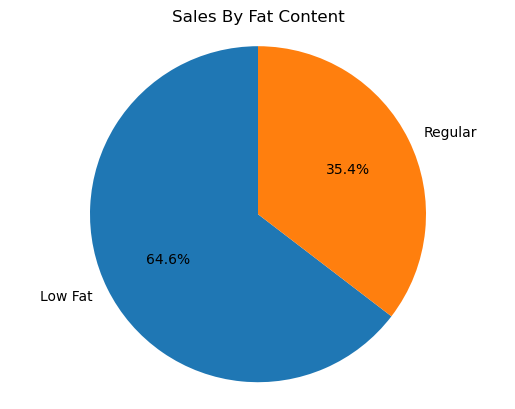

In [29]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()

plt.pie(sales_by_fat,labels=sales_by_fat.index,
                      autopct='%.1f%%',
                       startangle=90)        

plt.title('Sales By Fat Content')
plt.axis('equal')
plt.show()

#### **Total Sales By Item Type**

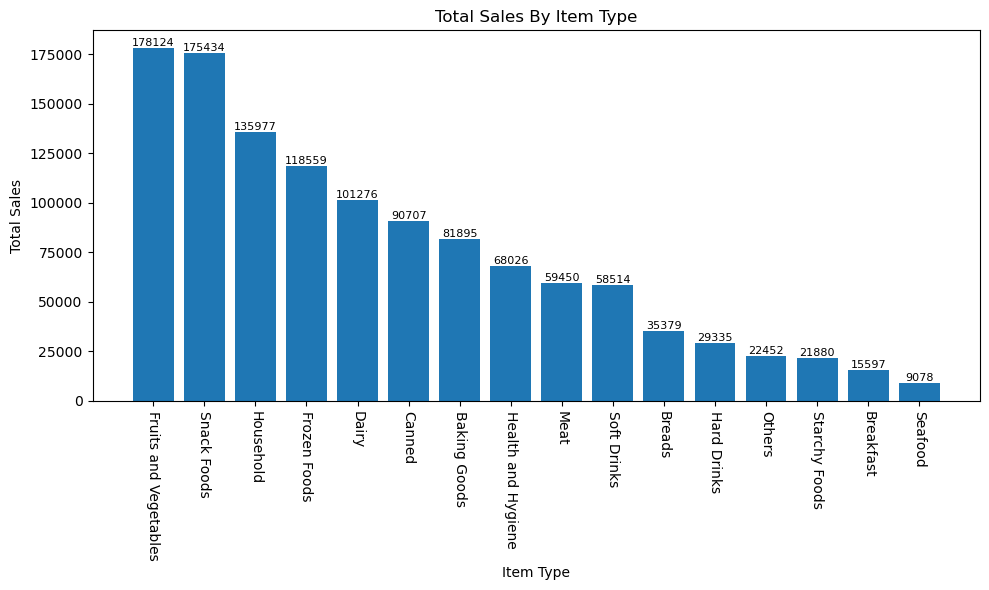

In [30]:
Sales_By_Type=df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
bars=plt.bar(Sales_By_Type.index,Sales_By_Type.values)

plt.xticks(rotation=-90)
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title('Total Sales By Item Type')

for x, y in zip(Sales_By_Type.index, Sales_By_Type.values):
    plt.text(x, y, f'{y:.0f}', ha='center', va='bottom', fontsize=8)



plt.tight_layout()
plt.show()
 

   
     

#### **Fat Content By Outlet For Total Sales**

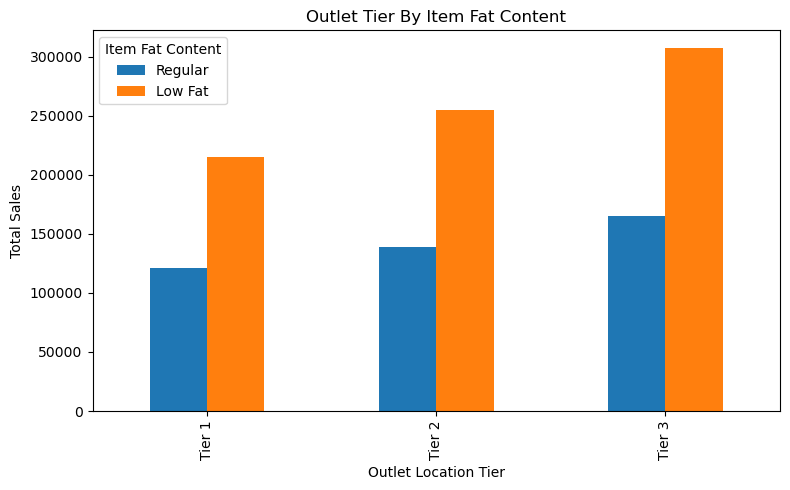

In [31]:
grouped = df.groupby(['Outlet Location Type', 'Item Fat Content'])['Sales'].sum().unstack()
grouped=grouped[['Regular','Low Fat']]

ax=grouped.plot(kind='bar',figsize=(8,5),title='Outlet Tier By Item Fat Content')
plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
ax.legend(title='Item Fat Content')
plt.tight_layout()
plt.show()

#### **Total Sales By Outlet Establishment**

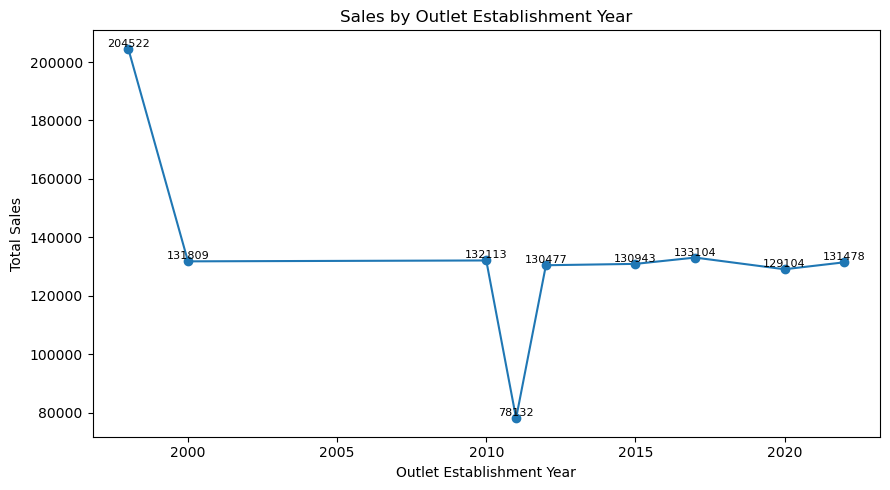

In [32]:
Sales_By_Year = (   df.groupby ('Outlet Establishment Year')['Sales']  .sum()  .sort_index())
   
  
plt.figure(figsize=(9, 5))
plt.plot(Sales_By_Year.index,Sales_By_Year.values, marker='o', linestyle='-')
    
   

plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Sales by Outlet Establishment Year')

for x, y in zip(Sales_By_Year.index, Sales_By_Year.values):
    plt.text(x, y, f'{y:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
           

#### **Sales By Outlet Size**

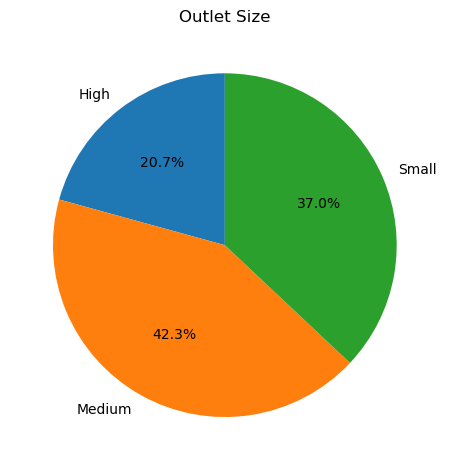

In [33]:
Sales_By_Size=df.groupby('Outlet Size')['Sales'].sum()

plt.Figure(figsize=(4,4))
plt.pie(Sales_By_Size,labels=Sales_By_Size.index, autopct="%1.1f%%", startangle=90)
plt.title('Outlet Size')
plt.tight_layout()           
plt.show()

#### **Sales By Outlet Location**


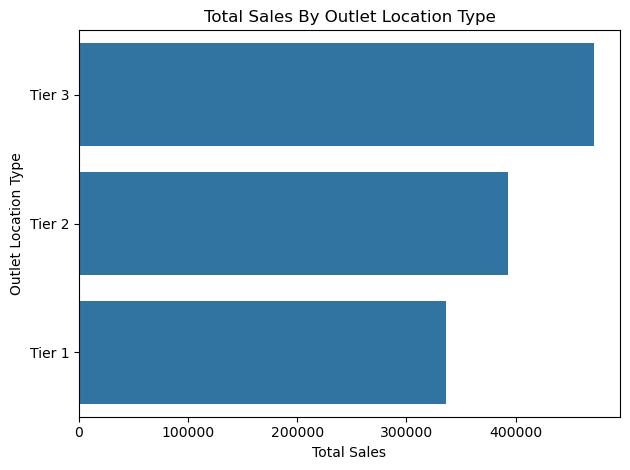

In [34]:
Sales_By_Location =df.groupby('Outlet Location Type')['Sales'].sum().reset_index()
Sales_By_Location=Sales_By_Location.sort_values('Sales',ascending=False)

plt.Figure(figsize=(8,3) ) #Smaller Height ,Enough Width
ax=sns.barplot(x='Sales',y='Outlet Location Type',data=Sales_By_Location)

      
plt.title('Total Sales By Outlet Location Type')
plt.xlabel('Total Sales')
plt.ylabel('Outlet Location Type')

plt.tight_layout()       #Ensures layout fits without scroll
plt.show()